# Bank Transaction Fraud Detection Across U.S. Cities
# DHURV VYAS 23BDS0012

**Dataset**: [Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection) (Kaggle)  
**Records**: 2,512 transactions

---
## 1. Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('bank_transactions_data_2.csv')

Saving bank_transactions_data_2.csv to bank_transactions_data_2.csv


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [3]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [4]:
print('Unique Values per Column:/n')

for col in df.columns:
    print(f'{col:30s}: {df[col].nunique():>6}')

Unique Values per Column:/n
TransactionID                 :   2512
AccountID                     :    495
TransactionAmount             :   2455
TransactionDate               :   2512
TransactionType               :      2
Location                      :     43
DeviceID                      :    681
IP Address                    :    592
MerchantID                    :    100
Channel                       :      3
CustomerAge                   :     63
CustomerOccupation            :      4
TransactionDuration           :    288
LoginAttempts                 :      5
AccountBalance                :   2510
PreviousTransactionDate       :    360


---
## 2. Data Cleaning & Preprocessing

In [5]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate TransactionIDs: {df["TransactionID"].duplicated().sum()}')

Duplicate rows: 0
Duplicate TransactionIDs: 0


In [6]:
q95_amount = df['TransactionAmount'].quantile(0.95)
q05_duration = df['TransactionDuration'].quantile(0.05)

print(f'Thresholds:')
print(f'  High Amount (>95th pctl):        > ${q95_amount:.2f}')
print(f'  Short Duration (<5th pctl):      < {q05_duration} seconds')
print(f'  High Login Attempts:             >= 2')

df['IsFraud'] = (
    (df['LoginAttempts'] >= 2) |
    (df['TransactionAmount'] > q95_amount) |
    (df['TransactionDuration'] < q05_duration)
).astype(int)

print(f'\nFraud Label Distribution:')
print(df['IsFraud'].value_counts())
print(f'\nFraud Rate: {df["IsFraud"].mean()*100:.2f}%')

Thresholds:
  High Amount (>95th pctl):        > $878.18
  Short Duration (<5th pctl):      < 24.0 seconds
  High Login Attempts:             >= 2

Fraud Label Distribution:
IsFraud
0    2162
1     350
Name: count, dtype: int64

Fraud Rate: 13.93%


In [7]:
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDay'] = df['TransactionDate'].dt.dayofweek  # 0=Mon, 6=Sun
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DaysSincePrevTxn'] = (df['PreviousTransactionDate'] - df['TransactionDate']).dt.days.abs()

print('New features created: TransactionHour, TransactionDay, TransactionMonth, DaysSincePrevTxn')
df[['TransactionDate', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'DaysSincePrevTxn']].head()

New features created: TransactionHour, TransactionDay, TransactionMonth, DaysSincePrevTxn


,TransactionDate,TransactionHour,TransactionDay,TransactionMonth,DaysSincePrevTxn
0,2023-04-11 16:29:14,16,1,4,572
1,2023-06-27 16:44:19,16,1,6,495
2,2023-07-10 18:16:08,18,0,7,482
3,2023-05-05 16:32:11,16,4,5,548
4,2023-10-16 17:51:24,17,0,10,384


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Fraud Distribution

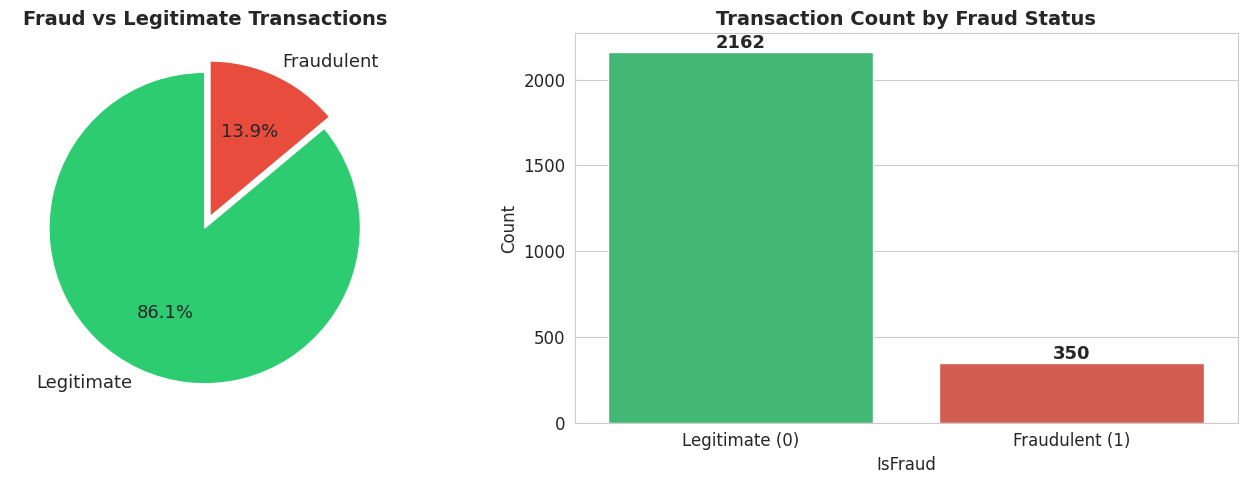

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = ['Legitimate', 'Fraudulent']
sizes = df['IsFraud'].value_counts().values
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13}, explode=(0, 0.08))
axes[0].set_title('Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(x='IsFraud', data=df, palette=colors, ax=axes[1])
axes[1].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[1].set_title('Transaction Count by Fraud Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Fraud by Location (Top 15 Cities)

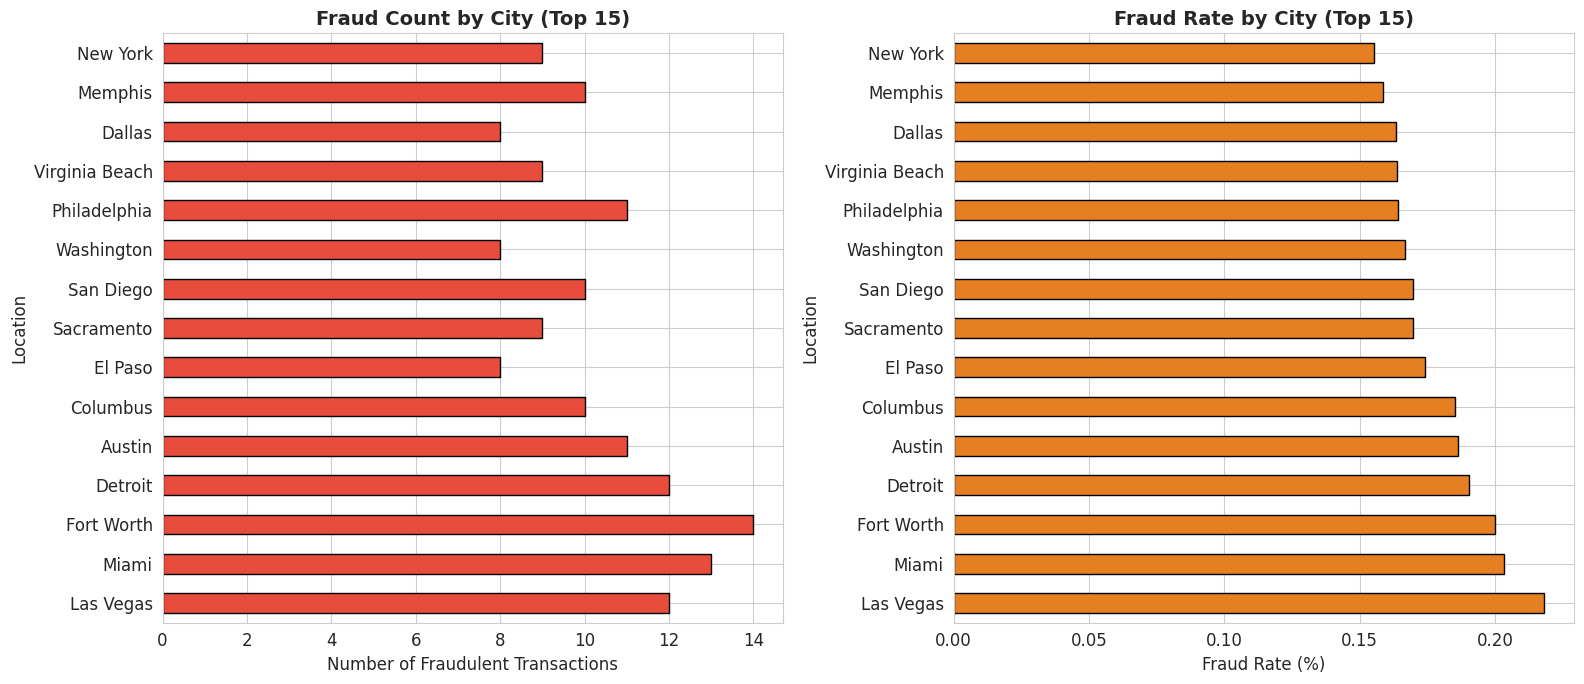


Top 5 Cities by Fraud Rate:
            FraudCount  TotalTxns  FraudRate
Location                                    
Las Vegas           12         55   0.218182
Miami               13         64   0.203125
Fort Worth          14         70   0.200000
Detroit             12         63   0.190476
Austin              11         59   0.186441


In [9]:
fraud_by_location = df.groupby('Location')['IsFraud'].agg(['sum', 'count', 'mean'])
fraud_by_location.columns = ['FraudCount', 'TotalTxns', 'FraudRate']
fraud_by_location = fraud_by_location.sort_values('FraudRate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fraud count by city
fraud_by_location['FraudCount'].plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Fraud Count by City (Top 15)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Fraudulent Transactions')

# Fraud rate by city
fraud_by_location['FraudRate'].plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Fraud Rate by City (Top 15)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

print('\nTop 5 Cities by Fraud Rate:')
print(fraud_by_location[['FraudCount', 'TotalTxns', 'FraudRate']].head())

### 3.3 Fraud by Channel & Transaction Type

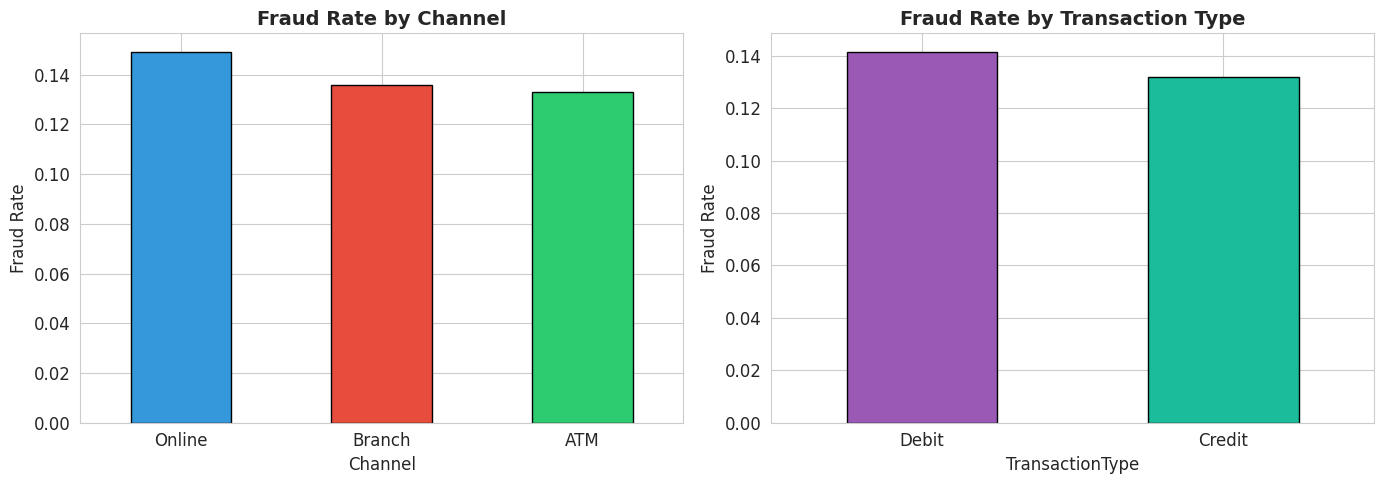

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Channel
channel_fraud = df.groupby('Channel')['IsFraud'].mean().sort_values(ascending=False)
channel_fraud.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Fraud Rate by Channel', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# By Transaction Type
type_fraud = df.groupby('TransactionType')['IsFraud'].mean().sort_values(ascending=False)
type_fraud.plot(kind='bar', ax=axes[1], color=['#9b59b6', '#1abc9c'], edgecolor='black')
axes[1].set_title('Fraud Rate by Transaction Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 3.4 Fraud by Customer Occupation & Age

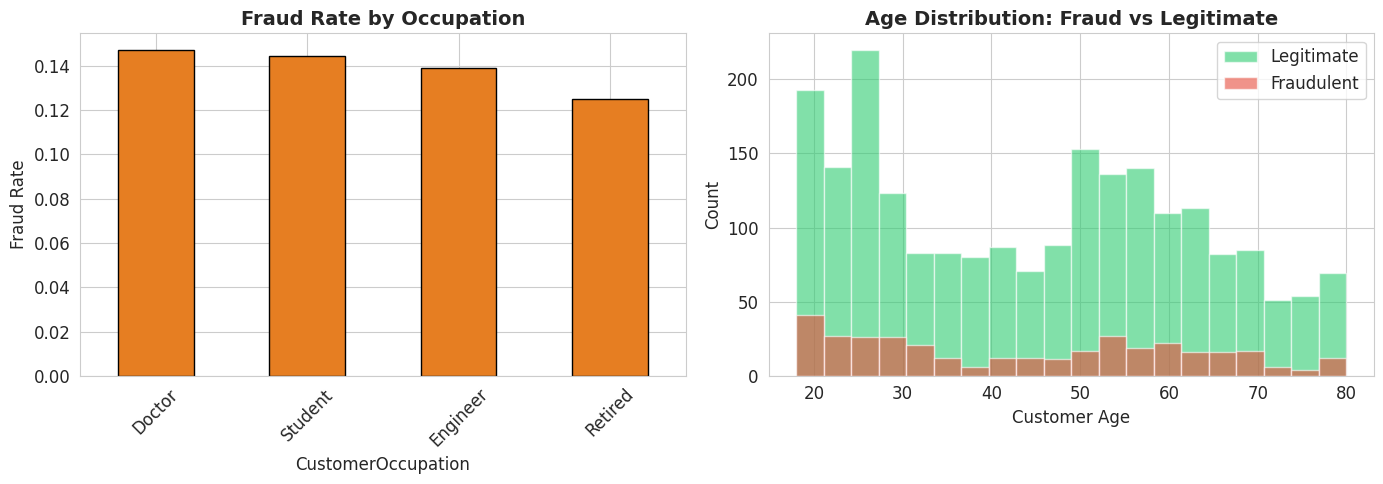

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Occupation
occ_fraud = df.groupby('CustomerOccupation')['IsFraud'].mean().sort_values(ascending=False)
occ_fraud.plot(kind='bar', ax=axes[0], color='#e67e22', edgecolor='black')
axes[0].set_title('Fraud Rate by Occupation', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Age distribution: fraud vs legit
axes[1].hist(df[df['IsFraud']==0]['CustomerAge'], bins=20, alpha=0.6, label='Legitimate', color='#2ecc71')
axes[1].hist(df[df['IsFraud']==1]['CustomerAge'], bins=20, alpha=0.6, label='Fraudulent', color='#e74c3c')
axes[1].set_title('Age Distribution: Fraud vs Legitimate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.5 Transaction Amount Analysis

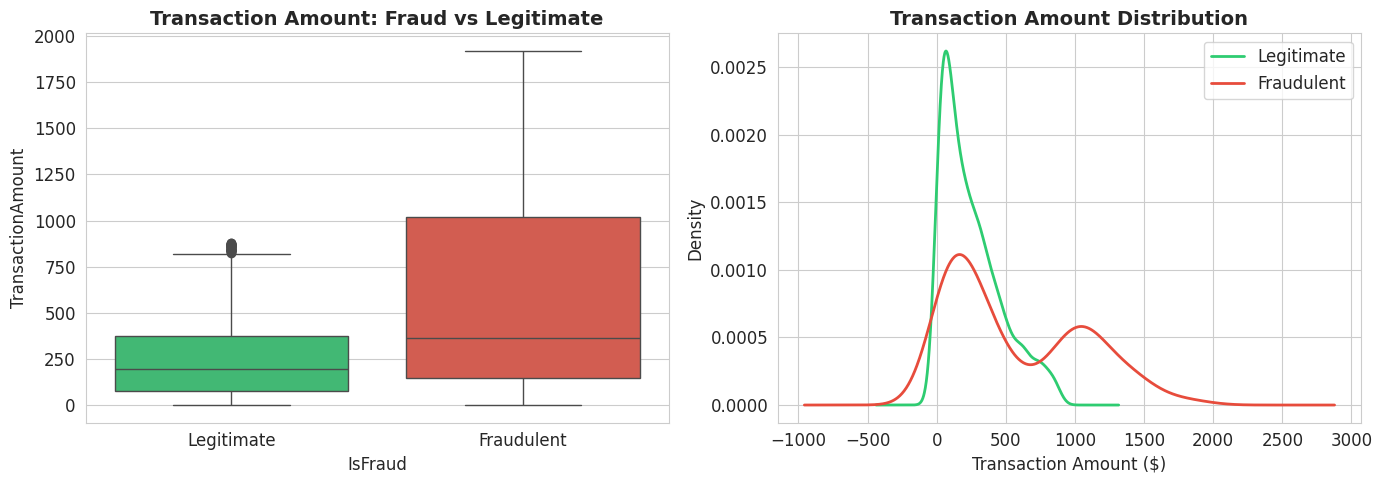

Mean Transaction Amount:
  Legitimate: $252.85
  Fraudulent: $573.99


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x='IsFraud', y='TransactionAmount', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[0].set_title('Transaction Amount: Fraud vs Legitimate', fontsize=14, fontweight='bold')

# KDE plot
df[df['IsFraud']==0]['TransactionAmount'].plot(kind='kde', ax=axes[1], label='Legitimate', color='#2ecc71', linewidth=2)
df[df['IsFraud']==1]['TransactionAmount'].plot(kind='kde', ax=axes[1], label='Fraudulent', color='#e74c3c', linewidth=2)
axes[1].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Mean Transaction Amount:')
print(f"  Legitimate: ${df[df['IsFraud']==0]['TransactionAmount'].mean():.2f}")
print(f"  Fraudulent: ${df[df['IsFraud']==1]['TransactionAmount'].mean():.2f}")

In [13]:
import folium
from folium.plugins import HeatMap

# City coordinates lookup
city_coords = {
    'Las Vegas':(36.17,-115.14), 'Miami':(25.76,-80.19), 'Fort Worth':(32.75,-97.33),
    'Detroit':(42.33,-83.05), 'Austin':(30.27,-97.74), 'Columbus':(39.96,-82.99),
    'El Paso':(31.76,-106.44), 'Sacramento':(38.58,-121.49), 'San Diego':(32.72,-117.16),
    'Washington':(38.91,-77.04), 'Philadelphia':(39.95,-75.17), 'Virginia Beach':(36.85,-75.98),
    'Dallas':(32.78,-96.80), 'Memphis':(35.15,-90.05), 'New York':(40.71,-74.01),
    'San Jose':(37.34,-121.89), 'Colorado Springs':(38.83,-104.82), 'Oklahoma City':(35.47,-97.52),
    'Albuquerque':(35.08,-106.65), 'Nashville':(36.16,-86.78), 'Phoenix':(33.45,-112.07),
    'Houston':(29.76,-95.37), 'Louisville':(38.25,-85.76), 'San Antonio':(29.42,-98.49),
    'Kansas City':(39.10,-94.58), 'Milwaukee':(43.04,-87.91), 'Omaha':(41.26,-95.94),
    'Tucson':(32.22,-110.93), 'Portland':(45.52,-122.68), 'Raleigh':(35.78,-78.64),
    'Charlotte':(35.23,-80.84), 'Baltimore':(39.29,-76.61), 'Jacksonville':(30.33,-81.66),
    'Seattle':(47.61,-122.33), 'Boston':(42.36,-71.06), 'Denver':(39.74,-104.99),
    'Indianapolis':(39.77,-86.16), 'Los Angeles':(34.05,-118.24), 'Chicago':(41.88,-87.63),
    'San Francisco':(37.77,-122.42), 'Atlanta':(33.75,-84.39), 'Mesa':(33.41,-111.83),
    'Fresno':(36.74,-119.77)
}

# Compute fraud stats per city
city_fraud = df.groupby('Location').agg(
    TotalTxns=('IsFraud', 'count'),
    FraudCount=('IsFraud', 'sum'),
    FraudRate=('IsFraud', 'mean'),
    AvgFraudAmount=('TransactionAmount', 'mean')
).reset_index()

# Color function: green (safe) -> yellow -> red (risky)
def get_color(rate):
    if rate >= 0.18: return '#e74c3c'   # Red - high risk
    elif rate >= 0.14: return '#e67e22'  # Orange - medium risk
    elif rate >= 0.10: return '#f1c40f'  # Yellow - moderate
    else: return '#2ecc71'               # Green - low risk

# Create base map
m = folium.Map(location=[39.5, -98.35], zoom_start=4,
               tiles='CartoDB positron', control_scale=True)

# Add city markers
for _, row in city_fraud.iterrows():
    city = row['Location']
    if city in city_coords:
        lat, lng = city_coords[city]
        fraud_rate = row['FraudRate'] * 100
        color = get_color(row['FraudRate'])
        radius = max(5, row['FraudCount'] * 1.5)  # Scale by fraud count

        popup_html = f"""
        <div style='font-family: Arial; width: 180px;'>
            <h4 style='margin:0 0 6px 0; color:#2c3e50;'>{city}</h4>
            <table style='font-size:12px; width:100%;'>
                <tr><td>Total Transactions</td><td><b>{row['TotalTxns']}</b></td></tr>
                <tr><td>Fraud Cases</td><td style='color:red;'><b>{row['FraudCount']}</b></td></tr>
                <tr><td>Fraud Rate</td><td style='color:{color};'><b>{fraud_rate:.1f}%</b></td></tr>
                <tr><td>Avg Txn Amount</td><td><b>${row['AvgFraudAmount']:.0f}</b></td></tr>
            </table>
        </div>
        """

        folium.CircleMarker(
            location=[lat, lng],
            radius=radius,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"{city}: {fraud_rate:.1f}% fraud rate",
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            weight=2
        ).add_to(m)

# Add heatmap layer
heat_data = []
for _, row in city_fraud.iterrows():
    city = row['Location']
    if city in city_coords:
        lat, lng = city_coords[city]
        heat_data.append([lat, lng, row['FraudCount']])

HeatMap(heat_data, radius=35, blur=25, max_zoom=6, min_opacity=0.4).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            border: 1px solid #ccc; font-size: 12px; font-family: Arial;">
    <b>Fraud Risk Level</b><br>
    <span style="color: #e74c3c;">&#9679;</span> High (&ge;18%)<br>
    <span style="color: #e67e22;">&#9679;</span> Medium (14-18%)<br>
    <span style="color: #f1c40f;">&#9679;</span> Moderate (10-14%)<br>
    <span style="color: #2ecc71;">&#9679;</span> Low (&lt;10%)<br>
    <i>Circle size = fraud count</i>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

print('Interactive fraud hotspot map generated!')
print(f'Cities mapped: {len(city_coords)}')
print(f'\nTop 5 riskiest cities:')
top5 = city_fraud.sort_values('FraudRate', ascending=False).head(5)
for _, r in top5.iterrows():
    print(f"  {r['Location']:20s} — {r['FraudRate']*100:.1f}% fraud rate ({r['FraudCount']} cases)")

m  # Renders inline in Jupyter/Colab

Interactive fraud hotspot map generated!
Cities mapped: 43

Top 5 riskiest cities:
  Las Vegas            — 21.8% fraud rate (12 cases)
  Miami                — 20.3% fraud rate (13 cases)
  Fort Worth           — 20.0% fraud rate (14 cases)
  Detroit              — 19.0% fraud rate (12 cases)
  Austin               — 18.6% fraud rate (11 cases)


---
## 4. Statistical Testing


In [14]:
from scipy import stats

fraud = df[df['IsFraud'] == 1]
legit = df[df['IsFraud'] == 0]

print('Two-Sample t-test — Transaction Amount')
print('=' * 65)
t_stat, p_val = stats.ttest_ind(fraud['TransactionAmount'], legit['TransactionAmount'])
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'Result: {"Reject H0 — Significant difference" if p_val < 0.05 else "Fail to reject H0 — No significant difference"}')
print()

Two-Sample t-test — Transaction Amount
t-statistic: 20.6449
p-value: 0.0000
Result: Reject H0 — Significant difference



In [15]:
print('Chi-Square Test — Channel vs Fraud')
print('=' * 65)
contingency = pd.crosstab(df['Channel'], df['IsFraud'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-Square Statistic: {chi2:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'Result: {"Reject H0 — Significant association" if p_val < 0.05 else "Fail to reject H0 — No significant association"}')
print()
print('Contingency Table:')
print(contingency)

Chi-Square Test — Channel vs Fraud
Chi-Square Statistic: 0.9981
p-value: 0.6071
Degrees of Freedom: 2
Result: Fail to reject H0 — No significant association

Contingency Table:
IsFraud    0    1
Channel          
ATM      722  111
Branch   750  118
Online   690  121


In [16]:
print('Chi-Square Test — Occupation vs Fraud')
print('=' * 65)
contingency2 = pd.crosstab(df['CustomerOccupation'], df['IsFraud'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency2)
print(f'Chi-Square Statistic: {chi2:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'Result: {"Reject H0 — Significant association" if p_val < 0.05 else "Fail to reject H0 — No significant association"}')

Chi-Square Test — Occupation vs Fraud
Chi-Square Statistic: 1.4896
p-value: 0.6847
Degrees of Freedom: 3
Result: Fail to reject H0 — No significant association


In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Select features for modeling
feature_cols = ['TransactionAmount', 'TransactionType', 'Location', 'Channel',
                'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
                'AccountBalance', 'TransactionHour', 'TransactionDay',
                'TransactionMonth', 'DaysSincePrevTxn']

df_model = df[feature_cols + ['IsFraud']].copy()

# Label encode categorical variables
label_encoders = {}
cat_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nFinal feature set shape: {df_model.shape}')
df_model.head()

TransactionType: {'Credit': np.int64(0), 'Debit': np.int64(1)}
Location: {'Albuquerque': np.int64(0), 'Atlanta': np.int64(1), 'Austin': np.int64(2), 'Baltimore': np.int64(3), 'Boston': np.int64(4), 'Charlotte': np.int64(5), 'Chicago': np.int64(6), 'Colorado Springs': np.int64(7), 'Columbus': np.int64(8), 'Dallas': np.int64(9), 'Denver': np.int64(10), 'Detroit': np.int64(11), 'El Paso': np.int64(12), 'Fort Worth': np.int64(13), 'Fresno': np.int64(14), 'Houston': np.int64(15), 'Indianapolis': np.int64(16), 'Jacksonville': np.int64(17), 'Kansas City': np.int64(18), 'Las Vegas': np.int64(19), 'Los Angeles': np.int64(20), 'Louisville': np.int64(21), 'Memphis': np.int64(22), 'Mesa': np.int64(23), 'Miami': np.int64(24), 'Milwaukee': np.int64(25), 'Nashville': np.int64(26), 'New York': np.int64(27), 'Oklahoma City': np.int64(28), 'Omaha': np.int64(29), 'Philadelphia': np.int64(30), 'Phoenix': np.int64(31), 'Portland': np.int64(32), 'Raleigh': np.int64(33), 'Sacramento': np.int64(34), 'San Anto

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,AccountBalance,TransactionHour,TransactionDay,TransactionMonth,DaysSincePrevTxn,IsFraud
0,14.09,1,36,0,70,0,81,5112.21,16,1,4,572,0
1,376.24,1,15,0,68,0,141,13758.91,16,1,6,495,0
2,126.29,1,23,2,19,3,56,1122.35,18,0,7,482,0
3,184.50,1,33,2,26,3,25,8569.06,16,4,5,548,0
4,13.45,0,1,2,26,3,198,7429.40,17,0,10,384,0


In [20]:
# Split into X and y
X = df_model.drop('IsFraud', axis=1)
y = df_model['IsFraud']

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test fraud rate:     {y_test.mean()*100:.2f}%')

# Scale numerical features
scaler = StandardScaler()
num_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
            'AccountBalance', 'TransactionHour', 'TransactionDay',
            'TransactionMonth', 'DaysSincePrevTxn']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Training set: 2009 samples
Test set:     503 samples

Training fraud rate: 13.94%
Test fraud rate:     13.92%


---
## 6. Machine Learning Modeling

We train three classifiers and handle class imbalance using `class_weight='balanced'`:
1. **Logistic Regression**
2. **Random Forest Classifier**
3. **Gradient Boosting (XGBoost-style via sklearn)**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

# Define models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                      'F1-Score': f1, 'AUC-ROC': auc, 'y_prob': y_prob, 'y_pred': y_pred}

    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'AUC-ROC:   {auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))


  Logistic Regression
Accuracy:  0.7435
Precision: 0.3190
Recall:    0.7429
F1-Score:  0.4464
AUC-ROC:   0.7852

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.74      0.83       433
       Fraud       0.32      0.74      0.45        70

    accuracy                           0.74       503
   macro avg       0.63      0.74      0.64       503
weighted avg       0.86      0.74      0.78       503


  Random Forest
Accuracy:  0.9622
Precision: 1.0000
Recall:    0.7286
F1-Score:  0.8430
AUC-ROC:   0.8575

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98       433
       Fraud       1.00      0.73      0.84        70

    accuracy                           0.96       503
   macro avg       0.98      0.86      0.91       503
weighted avg       0.96      0.96      0.96       503


  Gradient Boosting
Accuracy:  0.9583
Precision: 0.9623
Recall:    0.7286
F1-

### 6.1 Confusion Matrices

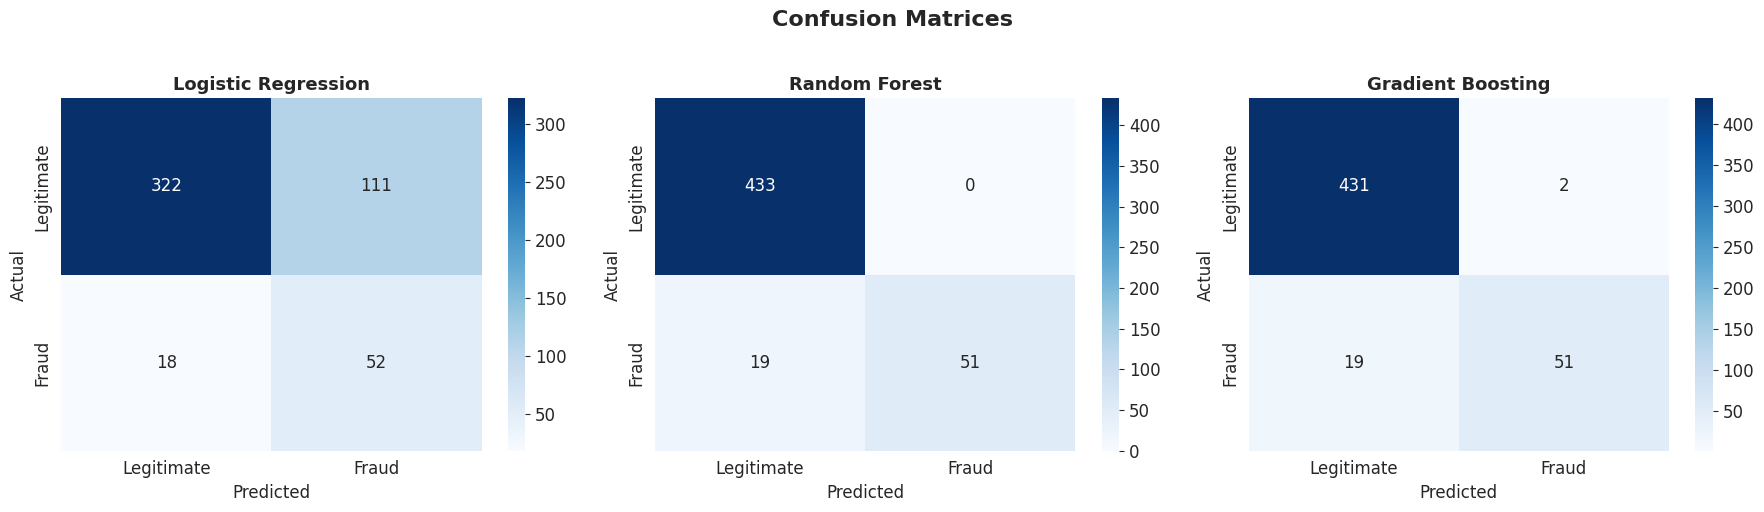

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Model Comparison Summary

In [24]:
# Summary table
summary = pd.DataFrame({name: {k: v for k, v in res.items() if k not in ['y_prob', 'y_pred']}
                        for name, res in results.items()}).T
summary = summary.round(4)
print('\n' + '=' * 70)
print('              MODEL COMPARISON SUMMARY')
print('=' * 70)
print(summary.to_string())
print('\n')

best_model = summary['AUC-ROC'].idxmax()
print(f'Best Model: {best_model} with AUC = {summary.loc[best_model, "AUC-ROC"]:.4f}')


              MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.7435     0.3190  0.7429    0.4464   0.7852
Random Forest          0.9622     1.0000  0.7286    0.8430   0.8575
Gradient Boosting      0.9583     0.9623  0.7286    0.8293   0.8840


Best Model: Gradient Boosting with AUC = 0.8840
